## Project Objective

The objective of this project is to analyze district-wise real estate pricing trends using monthly housing market data. The analysis focuses on understanding the relationship between property prices, rental prices, mortgage rates, and listing volumes across different districts over time.

Key objectives include:

Analyze trends in secondary and new-build property prices.
Compare rental prices across districts.
Identify districts with high and low property values.
Study the impact of mortgage rates and key interest rates on housing prices.
Understand monthly percentage changes in real estate prices.
Explore relationships between listings count and property price fluctuations.
Build predictive models to estimate property prices using regression techniques.

### 1. Basic Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

### 2. Data Understanding

In [2]:
df=pd.read_csv(r'C:\Users\ownert\Downloads\district_prices_monthly.csv')

In [3]:
df.head()

,year_month,district,okrug,secondary_price_per_sqm,newbuild_price_per_sqm,rental_price_per_sqm_monthly,secondary_mom_change_pct,newbuild_mom_change_pct,n_listings_secondary,n_listings_newbuild,n_listings_rental,cbr_key_rate_pct,avg_mortgage_rate_pct
0,2020-01,Arbat,CAO,480000,543700,2000,NaN,NaN,104,68,41,6.00,8.50
1,2020-02,Arbat,CAO,469100,531500,1955,-2.28,-2.24,22,63,50,6.00,8.50
2,2020-03,Arbat,CAO,502200,559800,2093,7.07,5.33,104,56,28,6.00,8.50
3,2020-04,Arbat,CAO,505100,541500,2104,0.56,-3.27,168,29,107,4.25,6.75
4,2020-05,Arbat,CAO,523500,594800,2181,3.65,9.84,66,58,57,4.25,6.75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year_month                    9804 non-null   object 
 1   district                      9804 non-null   object 
 2   okrug                         9804 non-null   object 
 3   secondary_price_per_sqm       9804 non-null   int64  
 4   newbuild_price_per_sqm        9804 non-null   int64  
 5   rental_price_per_sqm_monthly  9804 non-null   int64  
 6   secondary_mom_change_pct      9675 non-null   float64
 7   newbuild_mom_change_pct       9675 non-null   float64
 8   n_listings_secondary          9804 non-null   int64  
 9   n_listings_newbuild           9804 non-null   int64  
 10  n_listings_rental             9804 non-null   int64  
 11  cbr_key_rate_pct              9804 non-null   float64
 12  avg_mortgage_rate_pct         9804 non-null   float64
dtypes: 

In [5]:
df.columns

Index(['year_month', 'district', 'okrug', 'secondary_price_per_sqm',
       'newbuild_price_per_sqm', 'rental_price_per_sqm_monthly',
       'secondary_mom_change_pct', 'newbuild_mom_change_pct',
       'n_listings_secondary', 'n_listings_newbuild', 'n_listings_rental',
       'cbr_key_rate_pct', 'avg_mortgage_rate_pct'],
      dtype='object')

### 3. Data Cleaning
3.1 identifying missing or Null values

In [6]:
df.isnull().mean()*100

year_month                      0.000000
district                        0.000000
okrug                           0.000000
secondary_price_per_sqm         0.000000
newbuild_price_per_sqm          0.000000
rental_price_per_sqm_monthly    0.000000
secondary_mom_change_pct        1.315789
newbuild_mom_change_pct         1.315789
n_listings_secondary            0.000000
n_listings_newbuild             0.000000
n_listings_rental               0.000000
cbr_key_rate_pct                0.000000
avg_mortgage_rate_pct           0.000000
dtype: float64

In [7]:
df.dtypes

year_month                       object
district                         object
okrug                            object
secondary_price_per_sqm           int64
newbuild_price_per_sqm            int64
rental_price_per_sqm_monthly      int64
secondary_mom_change_pct        float64
newbuild_mom_change_pct         float64
n_listings_secondary              int64
n_listings_newbuild               int64
n_listings_rental                 int64
cbr_key_rate_pct                float64
avg_mortgage_rate_pct           float64
dtype: object

### 3.2 Filling Missing Values

In [8]:
df['secondary_mom_change_pct'].value_counts()

secondary_mom_change_pct
 1.53    19
 1.86    19
-0.62    18
 0.08    18
 0.67    17
         ..
 6.54     1
-4.99     1
 8.70     1
 8.28     1
-5.12     1
Name: count, Length: 1737, dtype: int64

In [9]:
df['secondary_mom_change_pct'].median()

0.6

In [10]:
df['secondary_mom_change_pct'].fillna(0.6,inplace=True)

In [11]:
df['secondary_mom_change_pct'].isnull().mean()*100

np.float64(0.0)

In [12]:
df['newbuild_mom_change_pct'].value_counts()

newbuild_mom_change_pct
0.08     18
1.89     17
1.99     15
0.43     15
0.54     15
         ..
14.97     1
12.13     1
7.71      1
13.07     1
12.69     1
Name: count, Length: 2259, dtype: int64

In [13]:
df['newbuild_mom_change_pct'].median()

0.52

In [14]:
df['newbuild_mom_change_pct'].fillna(0.52,inplace=True)

### 3.3 Removing Duplicate Values

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df=df.drop_duplicates()

In [17]:
df.describe(include='all')

,year_month,district,okrug,secondary_price_per_sqm,newbuild_price_per_sqm,rental_price_per_sqm_monthly,secondary_mom_change_pct,newbuild_mom_change_pct,n_listings_secondary,n_listings_newbuild,n_listings_rental,cbr_key_rate_pct,avg_mortgage_rate_pct
count,9804,9804,9804,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000,9804.000000
unique,76,129,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2020-01,Arbat,SVAO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,129,76,1292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,293669.543044,323147.460220,1223.625051,0.653084,0.710752,109.478070,42.461444,64.638821,11.986842,14.486842
std,NaN,NaN,NaN,123593.449575,136415.279338,514.966664,3.668673,5.115797,52.000534,21.655502,31.757889,5.712394,5.712394
min,NaN,NaN,NaN,70600.000000,74700.000000,294.000000,-13.090000,-15.630000,20.000000,5.000000,10.000000,4.250000,6.750000
25%,NaN,NaN,NaN,220400.000000,242375.000000,918.000000,-1.850000,-2.770000,64.000000,24.000000,38.000000,7.500000,10.000000
50%,NaN,NaN,NaN,274200.000000,301000.000000,1142.500000,0.600000,0.520000,110.000000,43.000000,65.000000,9.500000,12.000000
75%,NaN,NaN,NaN,344600.000000,379000.000000,1436.000000,3.092500,4.082500,155.000000,61.000000,92.000000,17.000000,19.500000


### 4. Exploratory Data Analysis

### 4.1 Univariate Analysis(NUMERICAL COLUMNS)

In [18]:
num_cols=df.select_dtypes(include='int64').columns

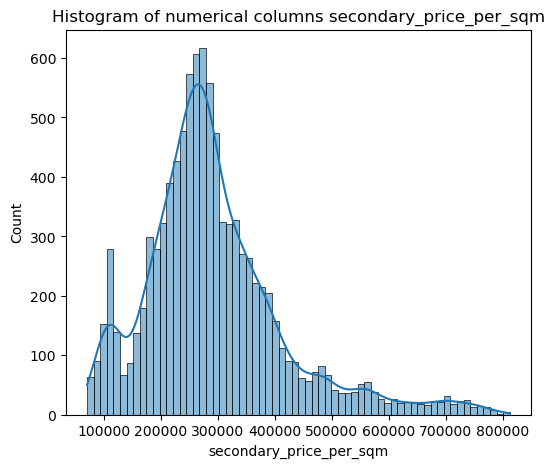

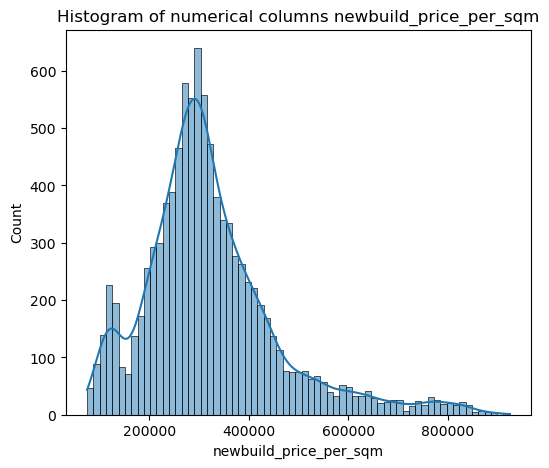

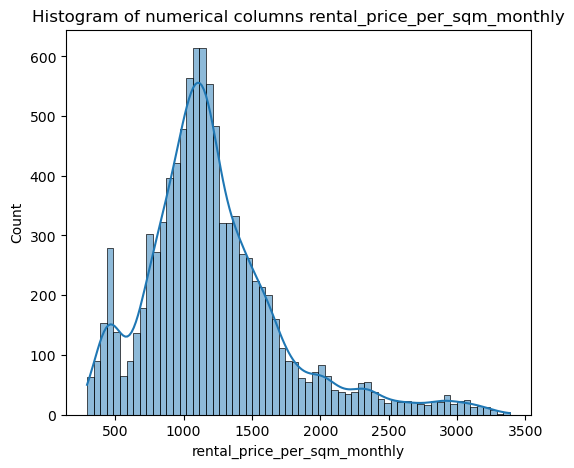

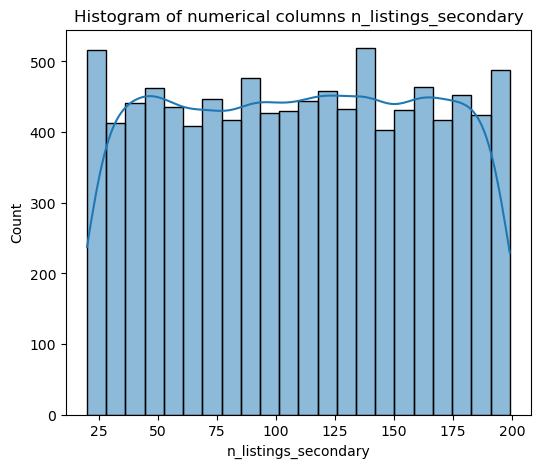

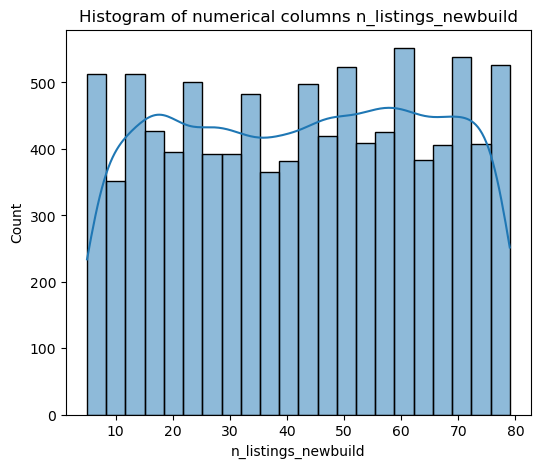

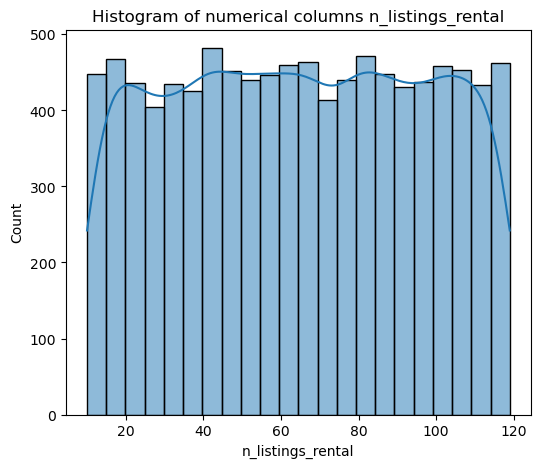

In [19]:
for a in num_cols:
    plt.figure(figsize=(6,5))
    sns.histplot(df[a],kde=True)
    plt.title(f'Histogram of numerical columns {a}')
    plt.show()

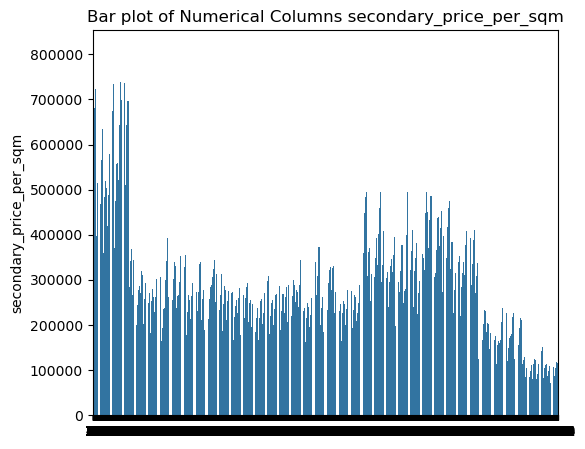

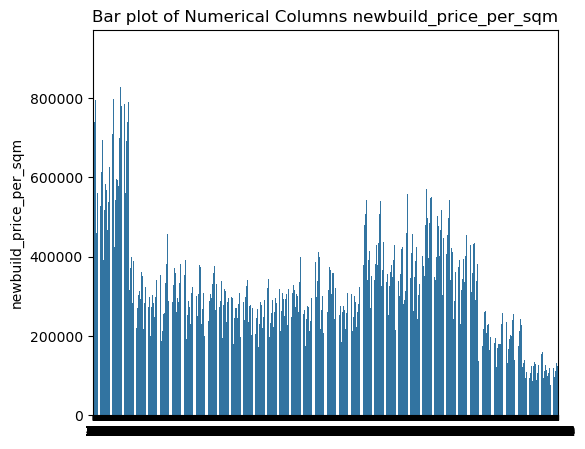

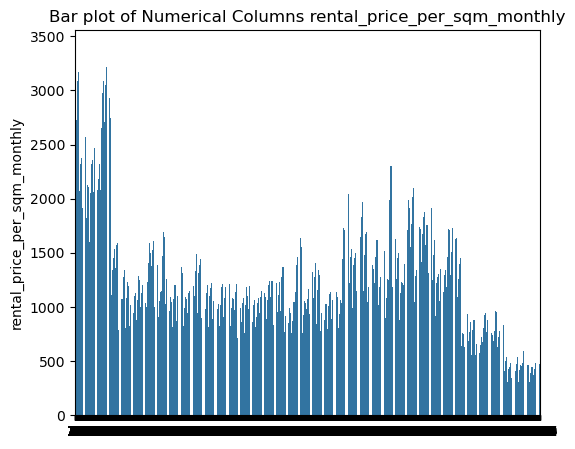

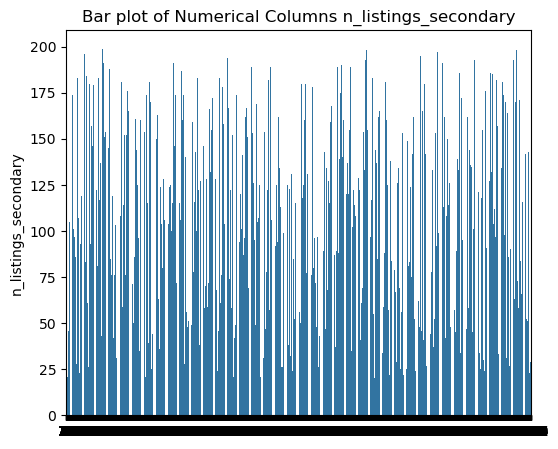

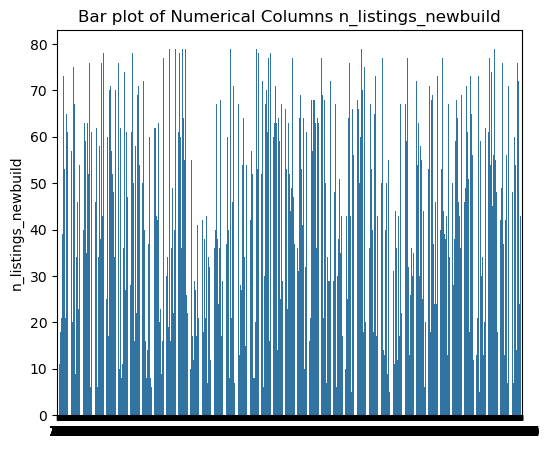

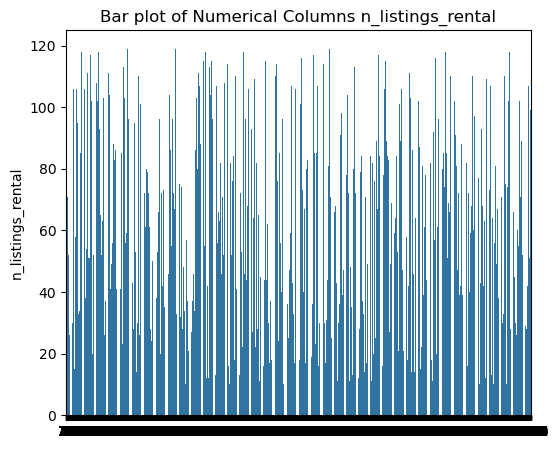

In [20]:
for a in num_cols:
    plt.figure(figsize=(6,5))
    sns.barplot(df[a])
    plt.title(f'Bar plot of Numerical Columns {a}')
    plt.show()

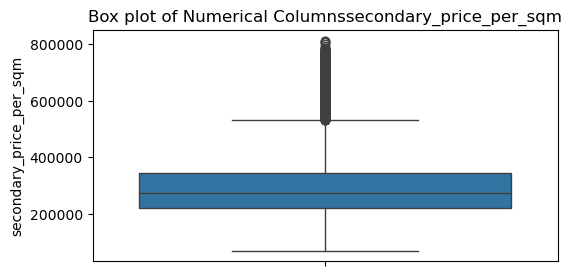

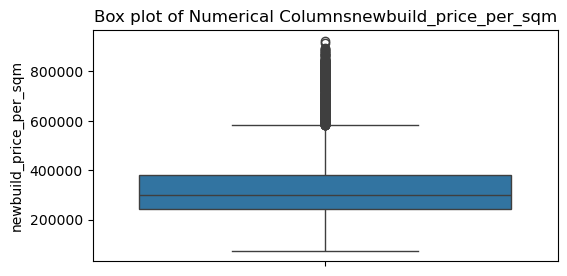

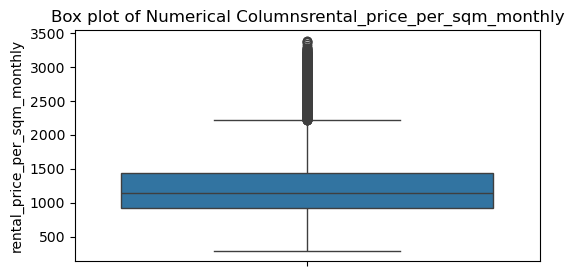

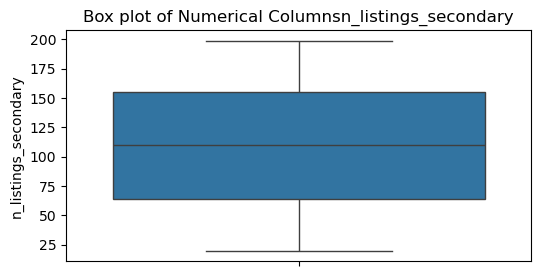

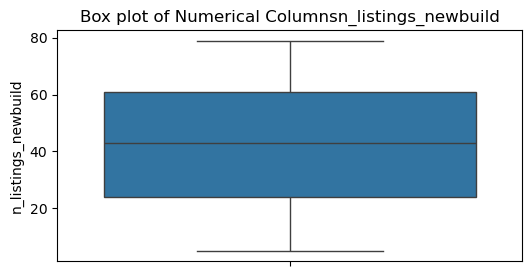

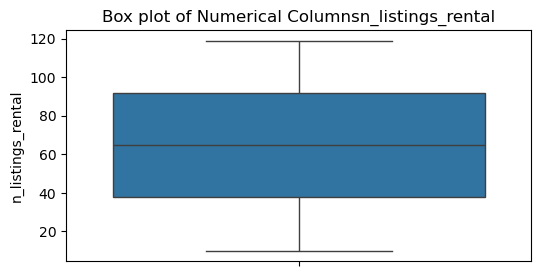

In [21]:
for a in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(df[a])
    plt.title(f'Box plot of Numerical Columns{a}')
    plt.show()

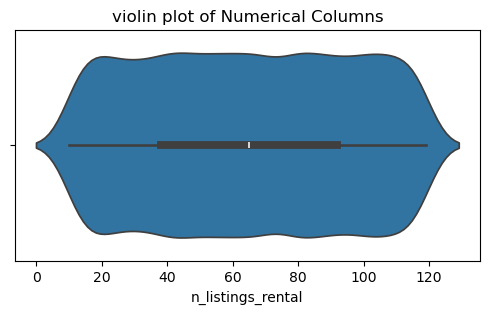

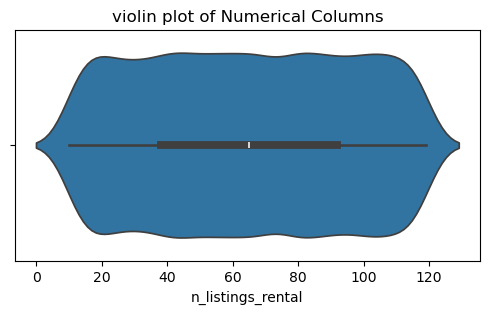

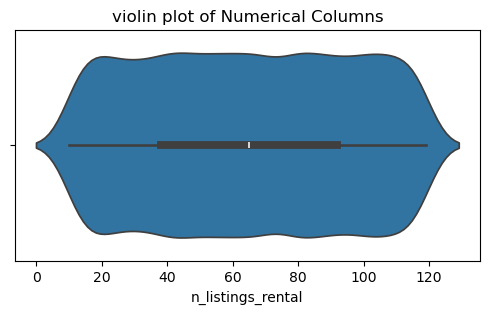

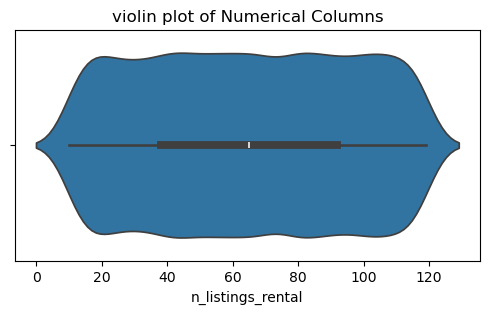

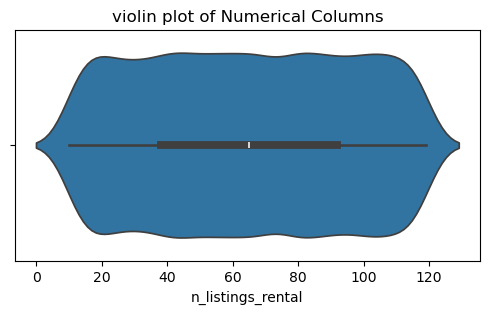

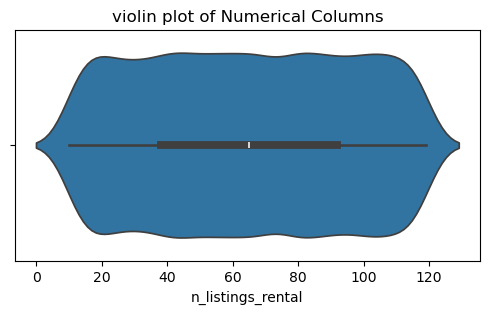

In [23]:
for a in num_cols:
    plt.figure(figsize=(6,3))
    sns.violinplot(x='n_listings_rental',data=df)
    plt.title('violin plot of Numerical Columns')
    plt.show()

### 4.2 Correlation Matrix

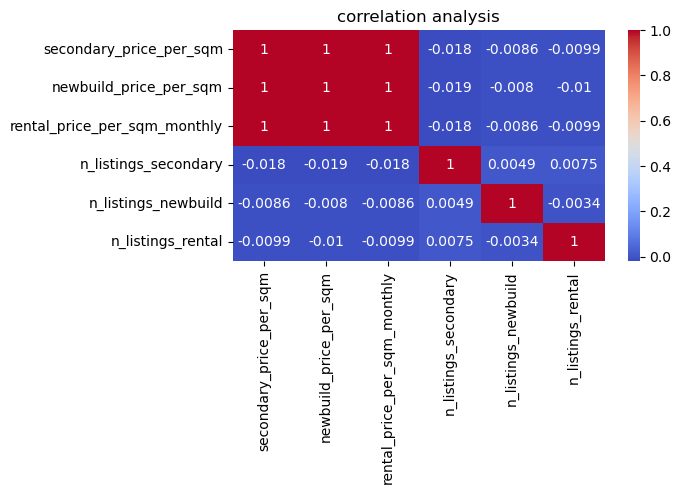

In [36]:
plt.figure(figsize=(6,3))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title('correlation analysis')
plt.show()

### 5. Bivariate Analysis

In [30]:
cat_cols=df.select_dtypes(include='object').columns

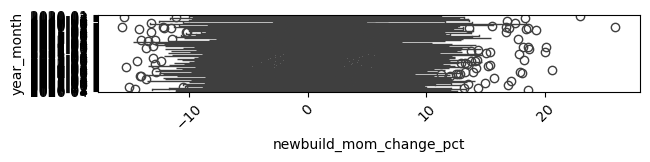

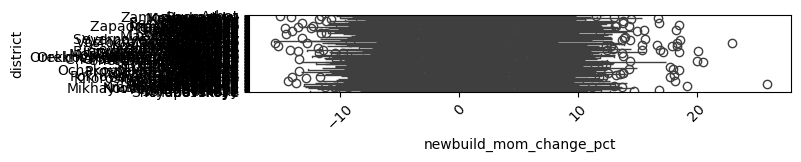

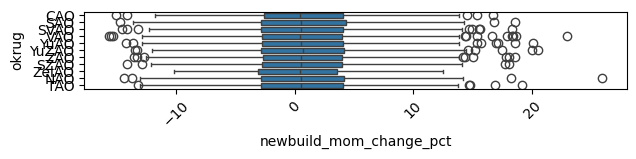

In [33]:
for b in cat_cols:
    plt.figure(figsize=(7,1))
    sns.boxplot(x='newbuild_mom_change_pct',y=b,data=df)
    plt.xticks(rotation=45)
    plt.show()

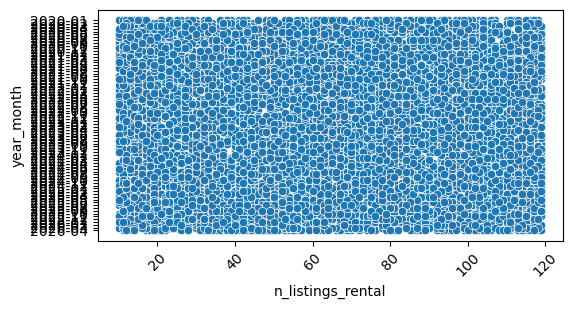

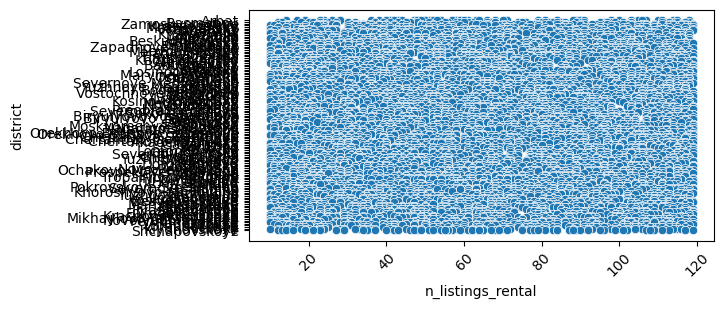

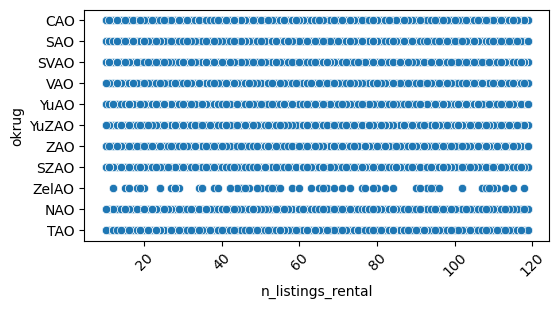

In [34]:
for b in cat_cols:
    plt.figure(figsize=(6,3))
    sns.scatterplot(x='n_listings_rental',y=b,data=df)
    plt.xticks(rotation=45)
    plt.show()

### 5. Feature Engineering
 5.1 applying iloc

In [43]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [39]:
df.columns

Index(['year_month', 'district', 'okrug', 'secondary_price_per_sqm',
       'newbuild_price_per_sqm', 'rental_price_per_sqm_monthly',
       'secondary_mom_change_pct', 'newbuild_mom_change_pct',
       'n_listings_secondary', 'n_listings_newbuild', 'n_listings_rental',
       'cbr_key_rate_pct', 'avg_mortgage_rate_pct'],
      dtype='object')

In [41]:
x=df.drop(columns=['avg_mortgage_rate_pct'],axis=1)
y=df['avg_mortgage_rate_pct']

In [44]:
x=pd.get_dummies(x,drop_first=True)

In [45]:
x.head()

,secondary_price_per_sqm,newbuild_price_per_sqm,rental_price_per_sqm_monthly,secondary_mom_change_pct,newbuild_mom_change_pct,n_listings_secondary,n_listings_newbuild,n_listings_rental,cbr_key_rate_pct,year_month_2020-02,...,okrug_NAO,okrug_SAO,okrug_SVAO,okrug_SZAO,okrug_TAO,okrug_VAO,okrug_YuAO,okrug_YuZAO,okrug_ZAO,okrug_ZelAO
0,480000,543700,2000,0.60,0.52,104,68,41,6.00,False,...,False,False,False,False,False,False,False,False,False,False
1,469100,531500,1955,-2.28,-2.24,22,63,50,6.00,True,...,False,False,False,False,False,False,False,False,False,False
2,502200,559800,2093,7.07,5.33,104,56,28,6.00,False,...,False,False,False,False,False,False,False,False,False,False
3,505100,541500,2104,0.56,-3.27,168,29,107,4.25,False,...,False,False,False,False,False,False,False,False,False,False
4,523500,594800,2181,3.65,9.84,66,58,57,4.25,False,...,False,False,False,False,False,False,False,False,False,False


In [46]:
y.head()

0    8.50
1    8.50
2    8.50
3    6.75
4    6.75
Name: avg_mortgage_rate_pct, dtype: float64

### 6. Model Building

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import train_test_split

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=100)

In [60]:
model=LinearRegression()

In [61]:
model.fit(x,y)

LinearRegression()

In [64]:
pred_test=model.predict(x_test)
score=r2_score(y_test,pred_test)

In [65]:
print("R2 Score:", score)

R2 Score: 1.0


## Project Conclusion

The exploratory data analysis revealed significant variations in property and rental prices across districts. New-build properties generally showed higher prices per square meter compared to secondary properties. Certain districts consistently maintained premium pricing, indicating strong market demand.

The analysis also showed that mortgage rates and central bank key rates influence housing price movements and market activity. Monthly price change percentages highlighted periods of rapid growth and market fluctuations.

Correlation analysis and visualizations helped identify important factors affecting property prices, including rental demand and listing availability. Regression modeling achieved a strong R² score, indicating that the selected features effectively explain housing price variations.

Overall, this project provides valuable insights into real estate market behavior and demonstrates how data analysis and machine learning can support property price prediction and market decision-making.